In [31]:
# ============================================================
# NOTEBOOK 6 — SHAP-GUIDED FEATURE SELECTION
# CELL 1 — IMPORT LIBRARIES
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
from pathlib import Path

print("Libraries imported successfully.")
print("SHAP version:", shap.__version__)

# ============================================================
# CELL 2 — DEFINE DIRECTORIES
# ============================================================
BASE_DIR = Path.cwd()
PROCESSED_DIR = BASE_DIR / "data/processed"
MODELS_DIR = BASE_DIR / "models"
RESULTS_DIR = BASE_DIR / "results"
PROCESSED_DIR = Path("../data/processed")

MODELS_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print("Project directory:", BASE_DIR)
print("Processed data:", PROCESSED_DIR)
print("Models:", MODELS_DIR)
print("Results:", RESULTS_DIR)

Libraries imported successfully.
SHAP version: 0.52.0
Project directory: c:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks
Processed data: ..\data\processed
Models: c:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks\models
Results: c:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks\results


In [5]:
# ============================================================
# CELL 3 — LOAD SMOTENC TRAINING DATA
# ============================================================
X_train_smotenc = pd.read_csv(
    PROCESSED_DIR / "X_train_smotenc.csv"
)
y_train_smotenc = pd.read_csv(
    PROCESSED_DIR / "y_train_smotenc.csv"
).squeeze()

print("=" * 60)
print("SMOTENC TRAINING DATA")
print("=" * 60)

print("X_train_smotenc shape:", X_train_smotenc.shape)
print("y_train_smotenc shape:", y_train_smotenc.shape)

print("\nTarget distribution:")
print(y_train_smotenc.value_counts().sort_index())

SMOTENC TRAINING DATA
X_train_smotenc shape: (658, 58)
y_train_smotenc shape: (658,)

Target distribution:
RISK_LABEL
0    329
1    329
Name: count, dtype: int64


In [6]:
# ============================================================
# CELL 4 — LOAD BASELINE XGBOOST MODEL
# ============================================================
baseline_model_path = MODELS_DIR / "baseline_xgboost.pkl"
baseline_xgb = joblib.load(
    baseline_model_path
)
print("Baseline XGBoost loaded successfully.")
print("\nModel:")
print(baseline_xgb)

Baseline XGBoost loaded successfully.

Model:
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=1.0, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)


In [7]:
# ============================================================
# CELL 5 — VERIFY MODEL/TRAINING DATA ALIGNMENT
# ============================================================

model_features = baseline_xgb.get_booster().feature_names
data_features = X_train_smotenc.columns.tolist()

print("Number of model features:", len(model_features))
print("Number of training features:", len(data_features))

print(
    "\nFeature names identical:",
    model_features == data_features
)

if model_features != data_features:

    print("\nWARNING — FEATURE MISMATCH")

    print("\nFeatures in model but not data:")
    print(set(model_features) - set(data_features))

    print("\nFeatures in data but not model:")
    print(set(data_features) - set(model_features))

else:
    print("✓ Model and training features are aligned.")

Number of model features: 58
Number of training features: 58

Feature names identical: True
✓ Model and training features are aligned.


In [8]:
# ============================================================
# CELL 6 — CREATE SHAP TREEEXPLAINER
# ============================================================
explainer = shap.TreeExplainer(
    baseline_xgb
)

print("SHAP TreeExplainer created successfully.")

SHAP TreeExplainer created successfully.


In [9]:
# ============================================================
# CELL 7 — CALCULATE SHAP VALUES
# ============================================================

print("Calculating SHAP values...")

shap_values = explainer.shap_values(
    X_train_smotenc
)

print("SHAP calculation completed.")

print("\nSHAP values shape:")
print(np.array(shap_values).shape)

Calculating SHAP values...
SHAP calculation completed.

SHAP values shape:
(658, 58)


In [10]:
# ============================================================
# CELL 8 — VERIFY SHAP OUTPUT
# ============================================================

print("SHAP object type:", type(shap_values))

if isinstance(shap_values, list):

    print("SHAP returned a list.")
    print("Number of SHAP arrays:", len(shap_values))

    for i, arr in enumerate(shap_values):
        print(f"SHAP array {i} shape:", np.array(arr).shape)

    # Binary classification: use positive class
    shap_matrix = np.array(shap_values[-1])

else:

    print("SHAP returned a single array.")

    shap_matrix = np.array(shap_values)

print("\nFinal SHAP matrix shape:", shap_matrix.shape)

SHAP object type: <class 'numpy.ndarray'>
SHAP returned a single array.

Final SHAP matrix shape: (658, 58)


In [11]:
# ============================================================
# CELL 9 — CALCULATE GLOBAL SHAP FEATURE IMPORTANCE
# ============================================================

mean_abs_shap = np.abs(shap_matrix).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": X_train_smotenc.columns,
    "Mean_ABS_SHAP": mean_abs_shap
})

shap_importance = shap_importance.sort_values(
    by="Mean_ABS_SHAP",
    ascending=False
).reset_index(drop=True)

shap_importance["SHAP_Rank"] = (
    np.arange(len(shap_importance)) + 1
)

print("=" * 70)
print("GLOBAL SHAP FEATURE IMPORTANCE")
print("=" * 70)

display(shap_importance)

GLOBAL SHAP FEATURE IMPORTANCE


,Feature,Mean_ABS_SHAP,SHAP_Rank
0,GPA_S1,1.459151,1
1,Hopeless/unmotivated,0.504815,2
2,Sleep_hrs,0.328824,3
3,LAB_AVG,0.293336,4
4,Programme prepares for career,0.258316,5
5,Concentration in self-study,0.246209,6
6,Adequate supervision,0.240706,7
7,CA_AVG,0.222517,8
8,Financial_diff,0.221595,9
9,Employment_hrs,0.218946,10


In [12]:
# ============================================================
# CELL 10 — TOP 20 SHAP FEATURES
# ============================================================

top_20_features = shap_importance.head(20)

print("=" * 70)
print("TOP 20 FEATURES BY MEAN ABSOLUTE SHAP VALUE")
print("=" * 70)

display(top_20_features)

TOP 20 FEATURES BY MEAN ABSOLUTE SHAP VALUE


,Feature,Mean_ABS_SHAP,SHAP_Rank
0,GPA_S1,1.459151,1
1,Hopeless/unmotivated,0.504815,2
2,Sleep_hrs,0.328824,3
3,LAB_AVG,0.293336,4
4,Programme prepares for career,0.258316,5
5,Concentration in self-study,0.246209,6
6,Adequate supervision,0.240706,7
7,CA_AVG,0.222517,8
8,Financial_diff,0.221595,9
9,Employment_hrs,0.218946,10


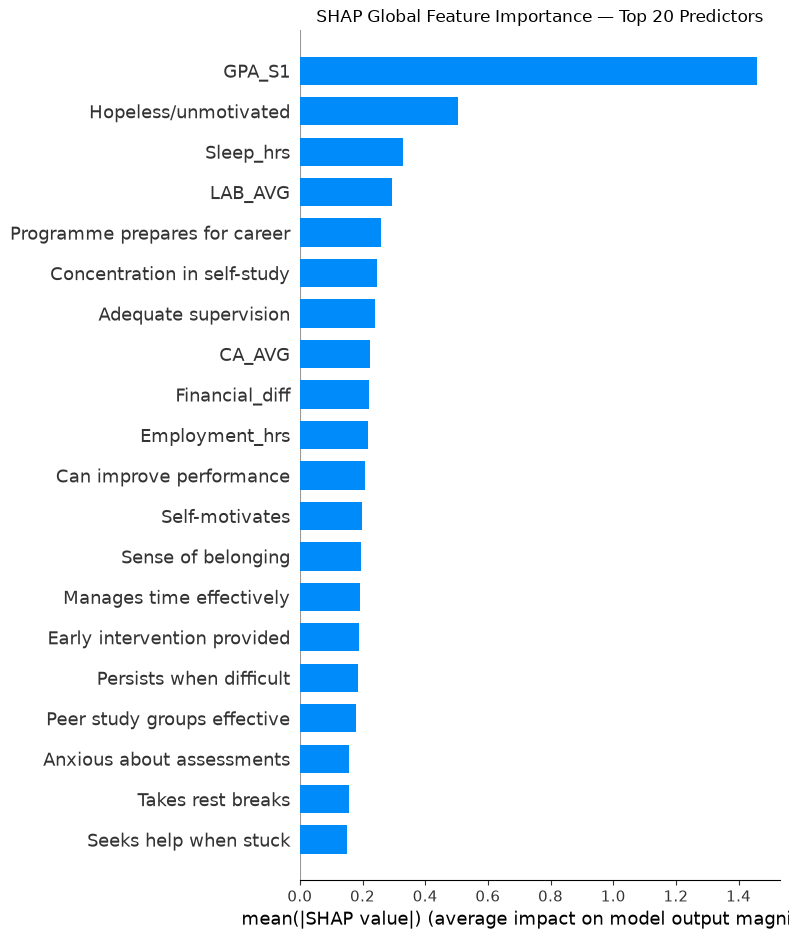

In [16]:
# ============================================================
# CELL 11 — SHAP GLOBAL FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(4, 3))

shap.summary_plot(
    shap_matrix,
    X_train_smotenc,
    plot_type="bar",
    max_display=20,
    show=False
)

plt.title(
    "SHAP Global Feature Importance — Top 20 Predictors"
)

plt.tight_layout()

plt.show()

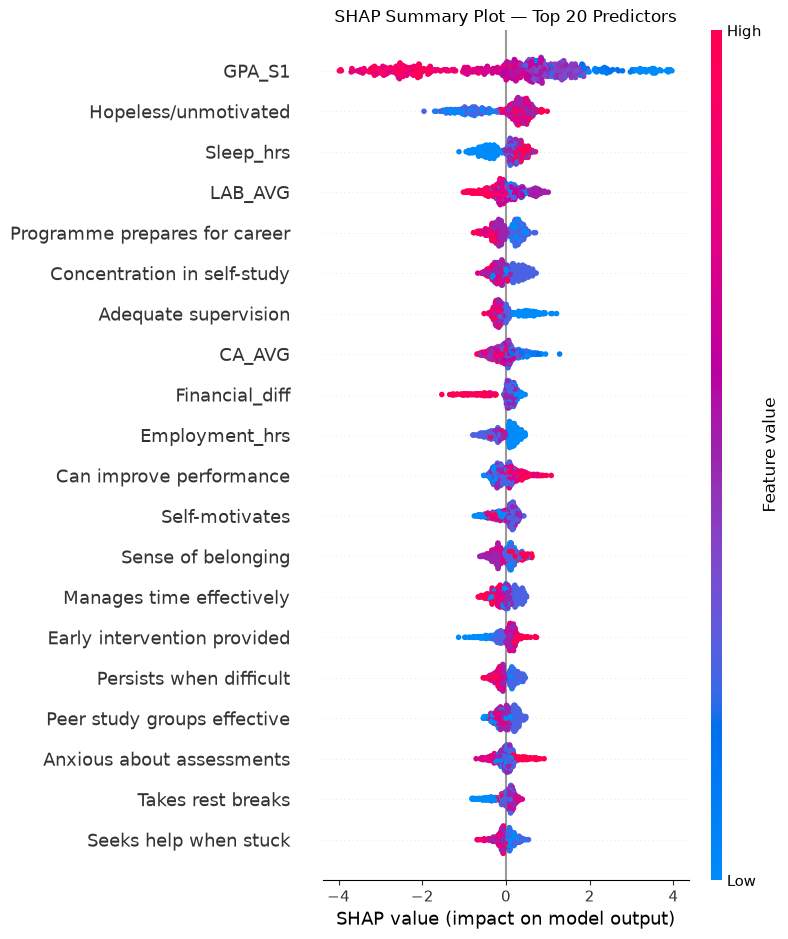

In [18]:
# ============================================================
# CELL 12 — SHAP SUMMARY BEESWARM PLOT
# ============================================================

plt.figure(figsize=(6, 5))

shap.summary_plot(
    shap_matrix,
    X_train_smotenc,
    max_display=20,
    show=False
)

plt.title(
    "SHAP Summary Plot — Top 20 Predictors"
)

plt.tight_layout()

plt.show()

In [19]:
# ============================================================
# CELL 13 — CUMULATIVE SHAP IMPORTANCE
# ============================================================

shap_importance["Cumulative_SHAP"] = (
    shap_importance["Mean_ABS_SHAP"].cumsum()
    / shap_importance["Mean_ABS_SHAP"].sum()
)

display(
    shap_importance.head(30)
)

,Feature,Mean_ABS_SHAP,SHAP_Rank,Cumulative_SHAP
0,GPA_S1,1.459151,1,0.166967
1,Hopeless/unmotivated,0.504815,2,0.224731
2,Sleep_hrs,0.328824,3,0.262358
3,LAB_AVG,0.293336,4,0.295923
4,Programme prepares for career,0.258316,5,0.325482
5,Concentration in self-study,0.246209,6,0.353655
6,Adequate supervision,0.240706,7,0.381198
7,CA_AVG,0.222517,8,0.406660
8,Financial_diff,0.221595,9,0.432017
9,Employment_hrs,0.218946,10,0.457070


In [20]:
# ============================================================
# CELL 14 — SHAP FEATURE SELECTION
# ============================================================

SHAP_THRESHOLD = 0.95

selected_features_df = shap_importance[
    shap_importance["Cumulative_SHAP"] <= SHAP_THRESHOLD
].copy()

# Ensure the first feature beyond the threshold is included
if len(selected_features_df) < len(shap_importance):

    next_feature_index = len(selected_features_df)

    selected_features_df = shap_importance.iloc[
        :next_feature_index + 1
    ].copy()

selected_features = selected_features_df[
    "Feature"
].tolist()

print("=" * 70)
print("SHAP FEATURE SELECTION")
print("=" * 70)

print("SHAP cumulative threshold:", SHAP_THRESHOLD)
print("Original number of features:", X_train_smotenc.shape[1])
print("Selected number of features:", len(selected_features))

print("\nSelected features:")
for i, feature in enumerate(selected_features, start=1):
    print(f"{i:02d}. {feature}")

SHAP FEATURE SELECTION
SHAP cumulative threshold: 0.95
Original number of features: 58
Selected number of features: 47

Selected features:
01. GPA_S1
02. Hopeless/unmotivated
03. Sleep_hrs
04. LAB_AVG
05. Programme prepares for career
06. Concentration in self-study
07. Adequate supervision
08. CA_AVG
09. Financial_diff
10. Employment_hrs
11. Can improve performance
12. Self-motivates
13. Sense of belonging
14. Manages time effectively
15. Early intervention provided
16. Persists when difficult
17. Peer study groups effective
18. Anxious about assessments
19. Takes rest breaks
20. Seeks help when stuck
21. Regular exercise
22. Participates in class
23. Considered break
24. Age_group
25. Understands content pre-exam
26. CLIN_AVG
27. Takes organised notes
28. Physical health affected
29. ATT_RATE
30. Lecturers approachable
31. Sets academic goals
32. Study_hrs_day
33. Completes readings
34. EXAM_AVG
35. Confident in clinical skills
36. Prepared for clinical assess
37. Rotations affect pe

In [21]:
# ============================================================
# CELL 15 — CREATE SHAP-SELECTED TRAINING DATA
# ============================================================

X_train_shap = X_train_smotenc[
    selected_features
].copy()

y_train_shap = y_train_smotenc.copy()

print("=" * 70)
print("SHAP-SELECTED TRAINING DATA")
print("=" * 70)

print("Original X_train shape:",
    X_train_smotenc.shape)

print("SHAP-selected X_train shape:",
    X_train_shap.shape)

print("y_train shape:",
    y_train_shap.shape)

print("\nTarget distribution:")
print(y_train_shap.value_counts().sort_index())

SHAP-SELECTED TRAINING DATA
Original X_train shape: (658, 58)
SHAP-selected X_train shape: (658, 47)
y_train shape: (658,)

Target distribution:
RISK_LABEL
0    329
1    329
Name: count, dtype: int64


In [22]:
# ============================================================
# CELL 16 — VERIFY SHAP-SELECTED DATA
# ============================================================

print("=" * 70)
print("SHAP-SELECTED DATA VALIDATION")
print("=" * 70)

print(
    "Missing values:",
    X_train_shap.isnull().sum().sum()
)

print(
    "Duplicate columns:",
    X_train_shap.columns.duplicated().sum()
)

print(
    "Number of observations:",
    X_train_shap.shape[0]
)

print(
    "Number of selected predictors:",
    X_train_shap.shape[1]
)

print(
    "Target observations:",
    y_train_shap.shape[0]
)

SHAP-SELECTED DATA VALIDATION
Missing values: 0
Duplicate columns: 0
Number of observations: 658
Number of selected predictors: 47
Target observations: 658


In [23]:
# ============================================================
# CELL 17 — SAVE SHAP FEATURE IMPORTANCE
# ============================================================

shap_importance_path = (
    RESULTS_DIR / "shap_feature_importance.csv"
)

shap_importance.to_csv(
    shap_importance_path,
    index=False
)

print("SHAP feature importance saved successfully.")
print("Saved to:", shap_importance_path)

SHAP feature importance saved successfully.
Saved to: c:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks\results\shap_feature_importance.csv


In [24]:
# ============================================================
# CELL 18 — SAVE SELECTED FEATURES
# ============================================================

selected_features_path = (
    RESULTS_DIR / "shap_selected_features.csv"
)

selected_features_df.to_csv(
    selected_features_path,
    index=False
)

print("Selected SHAP features saved successfully.")
print("Saved to:", selected_features_path)

Selected SHAP features saved successfully.
Saved to: c:\Users\HP\Documents\SP-XGBOOST\SP-Notebooks\results\shap_selected_features.csv


In [25]:
# ============================================================
# CELL 19 — SAVE SHAP-SELECTED TRAINING DATA
# ============================================================

X_train_shap.to_csv(
    PROCESSED_DIR / "X_train_shap.csv",
    index=False
)

y_train_shap.to_csv(
    PROCESSED_DIR / "y_train_shap.csv",
    index=False
)

print("SHAP-selected training data saved successfully.")

SHAP-selected training data saved successfully.


In [ ]:
# ============================================================
# CELL 20 — NOTEBOOK 6 SUMMARY
# ============================================================

print("=" * 75)
print("NOTEBOOK 6 — SHAP FEATURE SELECTION SUMMARY")
print("=" * 75)

print(f"Original training observations : {X_train_smotenc.shape[0]}")
print(f"Original predictors            : {X_train_smotenc.shape[1]}")
print(f"Selected predictors             : {X_train_shap.shape[1]}")
print(f"Features removed                : "
    f"{X_train_smotenc.shape[1] - X_train_shap.shape[1]}")

print(f"\nSHAP threshold                  : {SHAP_THRESHOLD:.0%}")

print("\nClass distribution:")
print(y_train_shap.value_counts().sort_index())

print("\nMissing values:")
print(X_train_shap.isnull().sum().sum())

print("\n✓ Notebook 6 SHAP feature selection completed.")

NOTEBOOK 6 — SHAP FEATURE SELECTION SUMMARY
Original training observations : 658
Original predictors            : 58
Selected predictors             : 47
Features removed                : 11

SHAP threshold                  : 95%

Class distribution:
RISK_LABEL
0    329
1    329
Name: count, dtype: int64

Missing values:
0

✓ Notebook 6 SHAP feature selection completed.
